### Background Info

- Manipulate and prepare the provided customer booking data to build a predictive model
- It's important to interpret the results in order to understand how "predictive" the data really is
- Evaluate the model’s performance and output how each variable contributes to the predictive model’s power.

### Task

**1. Explore and prepare the dataset**
- Explore `customer_booking.csv` (columns, dtypes, distributions, missing/invalid values).
- Engineer new features where useful, then prepare the data for modelling (encoding, scaling, etc.).

**2. Train a machine learning model**
- Predict `booking_complete` (whether the customer completes a booking).
- Use an algorithm that exposes feature-level contributions to predictive power (e.g. RandomForest).

**3. Evaluate the model and present findings**
- Cross-validate and report appropriate evaluation metrics.
- Visualise feature importance to interpret what drives the model.
- Summarise findings on a single slide (PowerPoint template, in Resources) for the manager — this is the final submission.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\nmark\Code\BA_Forage\ba-forage-data-science\data\customer_booking.csv", encoding="latin1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

Duplicate rows: 719


In [5]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [6]:
categorical_cols = df.select_dtypes(include="str").columns.tolist()
binary_cols = [c for c in df.columns if df[c].nunique() == 2]

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))
    print()

for col in binary_cols:
    print(f"{col}:")
    print(df[col].value_counts(dropna=False))
    print()

sales_channel: 2 unique values
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

trip_type: 3 unique values
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

flight_day: 7 unique values
flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64

route: 799 unique values
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

booking_origin: 104 unique values
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64

sales_channel:
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

wants_extra_baggage:
wants_extra

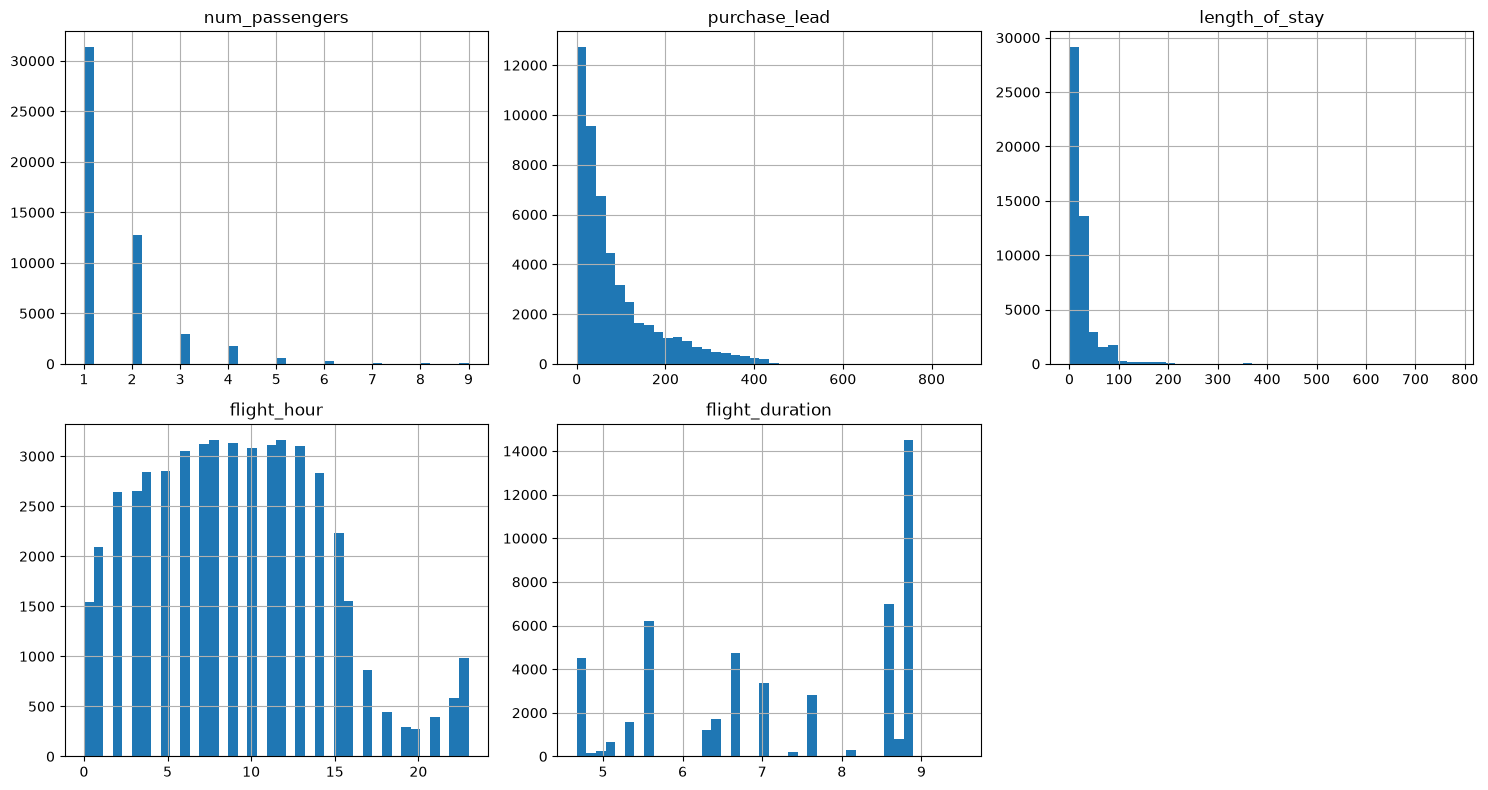

purchase_lead: upper IQR fence=256, max=867, rows above fence=3456
length_of_stay: upper IQR fence=62, max=778, rows above fence=3807


In [7]:
import matplotlib.pyplot as plt

numeric_cols = ["num_passengers", "purchase_lead", "length_of_stay", "flight_hour", "flight_duration"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].hist(bins=40, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

for col in ["purchase_lead", "length_of_stay"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    upper_fence = q3 + 1.5 * (q3 - q1)
    print(f"{col}: upper IQR fence={upper_fence:.0f}, "
          f"max={df[col].max()}, rows above fence={(df[col] > upper_fence).sum()}")

### Findings: exploration summary

- **Shape**: 50,000 rows × 14 columns. No missing values in any column. **719 exact duplicate rows** — worth deciding whether to drop these before modelling, since they'd otherwise let the same record influence both train and test folds.
- **Target (`booking_complete`)**: imbalanced — only **~15% of bookings complete** (7,478 / 50,000). This matters for model choice/evaluation: plain accuracy will be misleading, and `class_weight`/stratified CV should be used.
- **Categoricals**:
  - `sales_channel`: dominated by Internet (44,382) vs. Mobile (5,618).
  - `trip_type`: overwhelmingly RoundTrip (49,497); OneWay/CircleTrip are rare (<1% combined) — low variance, likely weak predictor.
  - `flight_day`: fairly even across the week (Mon highest ~8.1k, Sat lowest ~5.8k).
  - `route` (799 unique) and `booking_origin` (104 unique) are high-cardinality — too many levels for naive one-hot encoding; both are heavily concentrated in a handful of values (e.g. `AKLKUL` alone is 2,680 rows; Australia is 17,872 of `booking_origin`). Frequency encoding or grouping rare levels is worth considering.
  - Binary flags (`wants_extra_baggage`, `wants_preferred_seat`, `wants_in_flight_meals`) are all reasonably balanced (30-67% split), so likely useful signal.
- **Numerics — ranges look valid, no negative/impossible values**:
  - `num_passengers`: 1-9, heavily skewed toward 1-2 passengers (88% of rows).
  - `purchase_lead`: 0-867 days, right-skewed (median 51, mean 85) — a long tail of very-early bookings; ~3,456 rows sit above the IQR outlier fence (not necessarily errors, but worth flagging/transforming, e.g. log-scale, for modelling).
  - `length_of_stay`: 0-778 days, similarly right-skewed (median 17, mean 23); 778 days is an extreme outlier worth sanity-checking rather than assuming it's a data-entry mistake.
  - `flight_hour`: 0-23, valid full-day range.
  - `flight_duration`: 4.67-9.5 hours, tight and plausible range, no outliers by IQR fence.

**Implication for feature prep**: no missing-value imputation needed, but do decide on (a) dropping/keeping the 719 duplicates, (b) how to encode `route`/`booking_origin` given their cardinality, and (c) whether to log-transform `purchase_lead`/`length_of_stay` given their skew.